# 1854 Broad Street cholera outbreak
---

+ Confirmed cholera deaths
+ Water pump location (black square)

> Is the disease waterborne?

https://en.wikipedia.org/wiki/John_Snow

In [1]:
import pandas as pd
import pylab as plt
import matplotlib.colors as colors
import geopandas as gd
import contextily as cx
import warnings
import matplotlib.colors as colors

warnings.filterwarnings('ignore')
%matplotlib inline

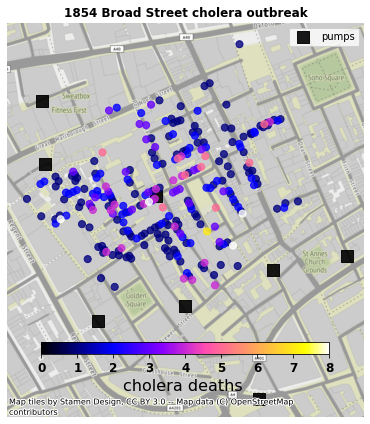

In [34]:
fig = plt.figure(figsize=[8,6])
ax=plt.gca()
cax = fig.add_axes([0.25,0.17,.5,.03])
plt.sca(ax)
df = gd.read_file('../datasets/SnowGIS_SHP/Cholera_Deaths.shp').to_crs('epsg:3857').sort_values('Count')

pf = gd.read_file('../datasets/SnowGIS_SHP/Pumps.shp').to_crs('epsg:3857')
pf.plot(ax=ax,color='k',markersize=130,marker='s',alpha=.9,label='pumps')
df.plot(column='Count',ax=ax,markersize=50,cax=cax,cmap='gnuplot2',norm=colors.Normalize(vmin=0.,vmax=8.),
        legend=True,legend_kwds={'orientation': "horizontal"},alpha=.8)
cx.add_basemap(ax, crs=df.crs.to_string())
ax.axis('off');
ax.legend()
ax.set_title('1854 Broad Street cholera outbreak',fontweight='bold')
plt.tight_layout()
plt.setp(cax.get_xticklabels(), fontsize=12,fontweight='bold')
cax.set_xlabel('cholera deaths ',fontsize=16);
plt.savefig('1854.png',dpi=600,bbox_inches='tight',transparent=True)

In [35]:
df

,Id,Count,geometry
249,0,1,POINT (-15335.608 6712339.425)
96,0,1,POINT (-15117.190 6712370.749)
187,0,1,POINT (-14993.571 6712804.021)
186,0,1,POINT (-15012.503 6712806.521)
99,0,1,POINT (-15044.203 6712374.145)
...,...,...,...
111,0,7,POINT (-15064.719 6712502.115)
117,0,8,POINT (-14960.620 6712554.121)
39,0,8,POINT (-15494.201 6712537.692)
113,0,8,POINT (-14988.576 6712460.393)


In [44]:
df1=df.to_crs(epsg='4326')
X=df1.geometry.x
Y=df1.geometry.y

In [54]:
df1=df1.assign(X=X,Y=Y)

In [59]:
X_=df1[['X','Y']].values
y_=df1.Count.values

In [61]:
y_

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,
        4,  4,  4,  4,  4

In [170]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.svm import SVR

#regr = RandomForestRegressor(max_depth=None,n_estimators=100).fit(X_,y_)


#regr = GradientBoostingRegressor(max_depth=None).fit(X_,y_)
#regr = ExtraTreesRegressor(max_depth=None,n_estimators=100).fit(X_,y_)
regr = BaggingRegressor(n_estimators=10,).fit(X_,y_)

print(regr.predict(X_),y_)

[ 1.3  1.1  1.   1.   1.5  2.2  1.6  1.   1.3  1.3  1.   1.2  1.1  1.2
  1.1  1.4  1.2  1.1  1.   1.   1.1  1.3  1.   1.   1.1  1.   1.1  1.
  1.   1.3  1.   1.   1.3  1.1  1.2  1.2  1.4  2.4  1.2  2.   1.8  1.6
  1.8  1.5  1.4  1.4  1.1  1.1  1.1  1.2  3.   3.   1.   1.   1.4  1.4
  1.1  1.7  2.   1.7  1.2  1.5  2.2  1.2  1.   2.   1.   1.3  1.1  1.7
  1.5  1.7  1.   1.   1.4  1.2  1.4  1.1  1.3  1.8  2.4  1.1  1.5  1.6
  1.1  1.3  1.2  1.2  1.4  2.4  1.   1.2  1.5  1.7  1.4  1.6  1.1  1.4
  1.3  1.4  2.3  1.4  2.8  1.8  2.1  1.   1.8  1.3  1.2  1.3  1.2  1.5
  1.5  2.1  1.1  1.9  1.2  1.1  1.4  1.5  1.   1.   2.7  1.4  1.3  1.
  1.5  1.3  1.3  1.6  1.8  1.   1.   1.   1.   1.5  2.3  2.6  1.9  1.9
  2.   2.2  1.8  2.2  2.1  1.8  1.8  2.3  1.6  2.   1.9  1.7  1.7  1.7
  1.9  1.8  2.4  1.6  2.7  2.   2.   1.9  1.5  1.8  1.9  1.9  1.8  1.7
  1.9  2.5  2.3  1.3  1.7  2.3  2.   2.   1.8  1.7  2.   2.1  2.6  2.2
  1.8  2.   2.1  1.9  1.9  2.   1.7  2.   2.1  2.   2.8  2.5  3.   2.8
  2.6  2

In [171]:
import numpy as np

X__,Y__ = np.mgrid[df1.X.values.min():df1.X.values.max():0.0001,df1.Y.values.min():df1.Y.values.max():0.0001]
xy = np.vstack((X__.flatten(), Y__.flatten())).T
dfXtest=pd.DataFrame(xy,columns=['X','Y'])

Xtest=dfXtest.values

In [172]:
Count=regr.predict(Xtest)

In [173]:
dfXtest=dfXtest.assign(Count=Count)
dfXtest

,X,Y,Count
0,-0.140074,51.511856,1.7
1,-0.140074,51.511956,2.6
2,-0.140074,51.512056,1.5
3,-0.140074,51.512156,1.5
4,-0.140074,51.512256,1.5
...,...,...,...
2875,-0.132974,51.515356,1.4
2876,-0.132974,51.515456,1.4
2877,-0.132974,51.515556,1.4
2878,-0.132974,51.515656,1.4


In [174]:
df2=pd.concat([df1,dfXtest])
df2.geometry=gd.points_from_xy(df2.X, df2.Y)
df2=df2.tail(dfXtest.index.size)
df2=df2.to_crs('epsg:3857').sort_values('Count')

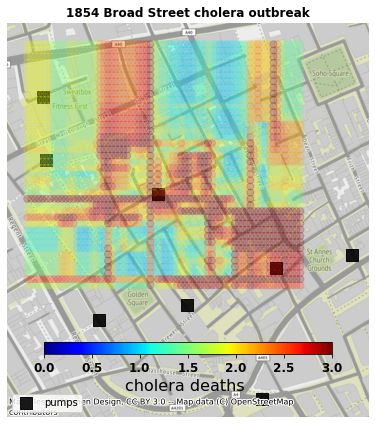

In [175]:
fig = plt.figure(figsize=[8,6])
ax=plt.gca()
cax = fig.add_axes([0.25,0.17,.5,.03])
plt.sca(ax)

pf = gd.read_file('../datasets/SnowGIS_SHP/Pumps.shp').to_crs('epsg:3857')
pf.plot(ax=ax,color='k',markersize=130,marker='s',alpha=.9,label='pumps')
df2.plot(column='Count',ax=ax,markersize=50,cax=cax,cmap='jet',norm=colors.Normalize(vmin=0.,vmax=3.),
        legend=True,legend_kwds={'orientation': "horizontal"},alpha=.2)
cx.add_basemap(ax, crs=df.crs.to_string())
ax.axis('off');
ax.legend()
ax.set_title('1854 Broad Street cholera outbreak',fontweight='bold')
plt.tight_layout()
plt.setp(cax.get_xticklabels(), fontsize=12,fontweight='bold')
cax.set_xlabel('cholera deaths ',fontsize=16);


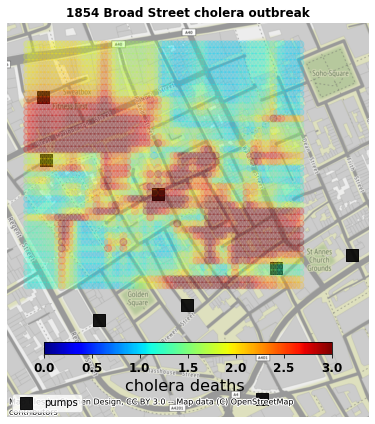

In [154]:
fig = plt.figure(figsize=[8,6])
ax=plt.gca()
cax = fig.add_axes([0.25,0.17,.5,.03])
plt.sca(ax)

pf = gd.read_file('../datasets/SnowGIS_SHP/Pumps.shp').to_crs('epsg:3857')
pf.plot(ax=ax,color='k',markersize=130,marker='s',alpha=.9,label='pumps')
df2.plot(column='Count',ax=ax,markersize=50,cax=cax,cmap='jet',norm=colors.Normalize(vmin=0.,vmax=3.),
        legend=True,legend_kwds={'orientation': "horizontal"},alpha=.2)
cx.add_basemap(ax, crs=df.crs.to_string())
ax.axis('off');
ax.legend()
ax.set_title('1854 Broad Street cholera outbreak',fontweight='bold')
plt.tight_layout()
plt.setp(cax.get_xticklabels(), fontsize=12,fontweight='bold')
cax.set_xlabel('cholera deaths ',fontsize=16);


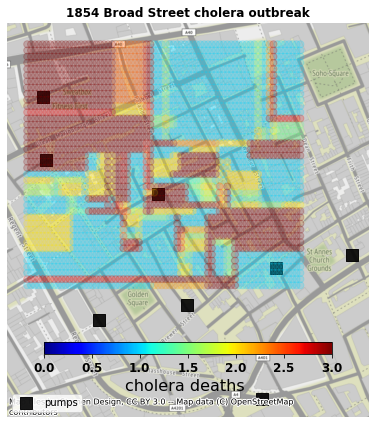

In [148]:
fig = plt.figure(figsize=[8,6])
ax=plt.gca()
cax = fig.add_axes([0.25,0.17,.5,.03])
plt.sca(ax)

pf = gd.read_file('../datasets/SnowGIS_SHP/Pumps.shp').to_crs('epsg:3857')
pf.plot(ax=ax,color='k',markersize=130,marker='s',alpha=.9,label='pumps')
df2.plot(column='Count',ax=ax,markersize=50,cax=cax,cmap='jet',norm=colors.Normalize(vmin=0.,vmax=3.),
        legend=True,legend_kwds={'orientation': "horizontal"},alpha=.2)
cx.add_basemap(ax, crs=df.crs.to_string())
ax.axis('off');
ax.legend()
ax.set_title('1854 Broad Street cholera outbreak',fontweight='bold')
plt.tight_layout()
plt.setp(cax.get_xticklabels(), fontsize=12,fontweight='bold')
cax.set_xlabel('cholera deaths ',fontsize=16);


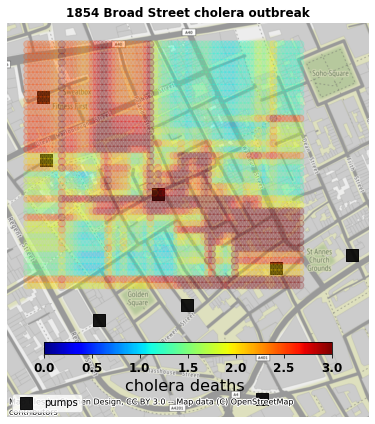

In [142]:
fig = plt.figure(figsize=[8,6])
ax=plt.gca()
cax = fig.add_axes([0.25,0.17,.5,.03])
plt.sca(ax)

pf = gd.read_file('../datasets/SnowGIS_SHP/Pumps.shp').to_crs('epsg:3857')
pf.plot(ax=ax,color='k',markersize=130,marker='s',alpha=.9,label='pumps')
df2.plot(column='Count',ax=ax,markersize=50,cax=cax,cmap='jet',norm=colors.Normalize(vmin=0.,vmax=3.),
        legend=True,legend_kwds={'orientation': "horizontal"},alpha=.2)
cx.add_basemap(ax, crs=df.crs.to_string())
ax.axis('off');
ax.legend()
ax.set_title('1854 Broad Street cholera outbreak',fontweight='bold')
plt.tight_layout()
plt.setp(cax.get_xticklabels(), fontsize=12,fontweight='bold')
cax.set_xlabel('cholera deaths ',fontsize=16);
